# Spatial domain detection using subcellularly informed representations

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import torch 
import numpy as np
import random
import pandas as pd
import os
from tqdm import tqdm
from scipy.sparse import lil_matrix
from scipy.sparse import save_npz, load_npz
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix 
from scipy.sparse.linalg import eigsh 
from sklearn.cluster import KMeans
import scanpy as sc

In [ ]:
data_path = './SVC/' 
dataset = 'data/xenium_mouse_brain' 
device = 'cuda:0'
gene_names = np.loadtxt(f'{data_path}{dataset}/gene_names.txt', dtype=str)
location_rep1 =  np.load(f"{data_path}{dataset}/cell_location_rep1.npy") 
location_rep2 = np.load(f"{data_path}{dataset}/cell_location_rep2.npy")

**due to the large size of tissue-level subcellular ST data, we can construct chunked sparse latent cell-cell adjacency matrices to avoid memory overflow**

In [3]:
cosine_simi_rep_1_part_1 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep1_part_1.npz')["cosine_simi_scaling"]
cosine_simi_rep_1_part_2 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep1_part_2.npz')["cosine_simi_scaling"]
cosine_simi_rep_1_part_3 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep1_part_3.npz')["cosine_simi_scaling"]

# cosine_simi_rep_2_part_1 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep2_part_1.npz')["cosine_simi_scaling"]
# cosine_simi_rep_2_part_2 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep2_part_2.npz')["cosine_simi_scaling"]
# cosine_simi_rep_2_part_3 = np.load(f'{data_path}output/xenium_mouse_brain/cosine_simi_scaling_rep2_part_3.npz')["cosine_simi_scaling"]

In [ ]:
### Convert to sparse matrices csr_D1, csr_D2, csr_D3 for replicate 1; csr_D4, csr_D5, csr_D6 for replicate 2

csr_D_1 = convert_to_csr1(cosine_simi_rep_1_part_1)
csr_D_2 = convert_to_csr1(cosine_simi_rep_1_part_2)
csr_D_3 = convert_to_csr1(cosine_simi_rep_1_part_3)

# csr_D_4 = convert_to_csr1(cosine_simi_rep_2_part_1)
# csr_D_5 = convert_to_csr1(cosine_simi_rep_2_part_2)
# csr_D_6 = convert_to_csr1(cosine_simi_rep_2_part_3)

### Convert to sparse matrices csr_D_12, csr_D_13, csr_D_23 for replicate 1; csr_D_45, csr_D_46, csr_D_56 for replicate 2; 

# csr_D_12 = convert_to_csr2(cosine_simi_rep_1_part_1, cosine_simi_rep_1_part_2)
# csr_D_13 = convert_to_csr2(cosine_simi_rep_1_part_1, cosine_simi_rep_1_part_3)
# csr_D_23 = convert_to_csr2(cosine_simi_rep_1_part_2, cosine_simi_rep_1_part_3)

# csr_D_45 = convert_to_csr2(cosine_simi_rep_2_part_1, cosine_simi_rep_2_part_2)
# csr_D_46 = convert_to_csr2(cosine_simi_rep_2_part_1, cosine_simi_rep_2_part_3)
# csr_D_56 = convert_to_csr2(cosine_simi_rep_2_part_2, cosine_simi_rep_2_part_3)

### Convert to sparse matrices csr_D_14, csr_D_15, csr_D_16, csr_D_24, csr_D_25, csr_D_26, csr_D_34, csr_D_35, csr_D_36 for cross-replicate

# csr_D_14 = convert_to_csr2(cosine_simi_rep_1_part_1, cosine_simi_rep_2_part_1)
# csr_D_15 = convert_to_csr2(cosine_simi_rep_1_part_1, cosine_simi_rep_2_part_2)
# csr_D_16 = convert_to_csr2(cosine_simi_rep_1_part_1, cosine_simi_rep_2_part_3)

# csr_D_24 = convert_to_csr2(cosine_simi_rep_1_part_2, cosine_simi_rep_2_part_1)
# csr_D_25 = convert_to_csr2(cosine_simi_rep_1_part_2, cosine_simi_rep_2_part_2)
# csr_D_26 = convert_to_csr2(cosine_simi_rep_1_part_2, cosine_simi_rep_2_part_3)

# csr_D_34 = convert_to_csr2(cosine_simi_rep_1_part_3, cosine_simi_rep_2_part_1)
# csr_D_35 = convert_to_csr2(cosine_simi_rep_1_part_3, cosine_simi_rep_2_part_2)
# csr_D_36 = convert_to_csr2(cosine_simi_rep_1_part_3, cosine_simi_rep_2_part_3)

100%|██████████| 30848/30848 [02:03<00:00, 249.21it/s] 


k: 10
Processed 0/30848 rows
Processed 5000/30848 rows
Processed 10000/30848 rows
Processed 15000/30848 rows
Processed 20000/30848 rows
Processed 25000/30848 rows
Processed 30000/30848 rows


100%|██████████| 30720/30720 [02:06<00:00, 243.72it/s] 


k: 10
Processed 0/30720 rows
Processed 5000/30720 rows
Processed 10000/30720 rows
Processed 15000/30720 rows
Processed 20000/30720 rows
Processed 25000/30720 rows
Processed 30000/30720 rows


100%|██████████| 31879/31879 [02:12<00:00, 241.46it/s] 


k: 10
Processed 0/31879 rows
Processed 5000/31879 rows
Processed 10000/31879 rows
Processed 15000/31879 rows
Processed 20000/31879 rows
Processed 25000/31879 rows
Processed 30000/31879 rows


In [ ]:
save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_1', csr_D_1)
save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_2', csr_D_2)
save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_3', csr_D_3)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_4', csr_D_4)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_5', csr_D_5)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_6', csr_D_6)

# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_12', csr_D_12)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_13', csr_D_13)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_23', csr_D_23)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_14', csr_D_14)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_15', csr_D_15)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_16', csr_D_16)

# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_24', csr_D_24)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_25', csr_D_25)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_26', csr_D_26)

# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_34', csr_D_34)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_35', csr_D_35)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_36', csr_D_36)

# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_45', csr_D_45)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_46', csr_D_46)
# save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/csr_D_56', csr_D_56)

**integrate all the csr matrices to construct the full cell-cell adjacency matrix**

In [ ]:
from pathlib import Path
from scipy.sparse import load_npz, bmat

base = Path(data_path) / "output/xenium_mouse_brain/domain_detection"

n_blocks = 6

blocks_dict = {}

for i in range(1, n_blocks + 1):
    blocks_dict[(i, i)] = load_npz(base / f"csr_D_{i}.npz")

for i in range(1, n_blocks + 1):
    for j in range(i + 1, n_blocks + 1):
        blocks_dict[(i, j)] = load_npz(base / f"csr_D_{i}{j}.npz")

blocks = [[None for _ in range(n_blocks)] for _ in range(n_blocks)]

for i in range(1, n_blocks + 1):
    for j in range(1, n_blocks + 1):
        if i == j:
            blocks[i - 1][j - 1] = blocks_dict[(i, i)]
        elif i < j:
            blocks[i - 1][j - 1] = blocks_dict[(i, j)]
        else:
            blocks[i - 1][j - 1] = blocks_dict[(j, i)].T

csr_matrices = bmat(blocks, format="csr")

print("shape of csr_matrices after integration:", csr_matrices.shape)

shape of csr_matrices after integration: (182067, 182067)


In [ ]:
def find_min_positive_per_row(matrix: csr_matrix, top_k: int = 10):
    matrix = matrix.tocsr()
    S = lil_matrix((matrix.shape[0], matrix.shape[1]))
    for i in tqdm(range(matrix.shape[0])):
        row_start = matrix.indptr[i]
        row_end = matrix.indptr[i+1]
        row_data = matrix.data[row_start:row_end]
        row_cols = matrix.indices[row_start:row_end]
        
        positive_mask = row_data > 0
        positive_data = row_data[positive_mask]
        positive_cols = row_cols[positive_mask]
        
        
        sorted_indices = np.argsort(positive_data)[:top_k]
        S[i,positive_cols[sorted_indices]] = 1
    S = S.tocsr()
    S = S.multiply(S.T)
    return S

S = find_min_positive_per_row(csr_matrices)
save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/adjacency_matrix_SVC.npz', S)

100%|██████████| 182067/182067 [00:07<00:00, 23361.38it/s]


**built a spatial cell-cell adjacency matrix based on the Euclidean distances between cells’ actual spatial coordinates**

In [ ]:
location = np.vstack((location_rep1, location_rep2))
N = location.shape[0]
S_spatial0 = lil_matrix((N, N))
k = 10
location_tensor = torch.Tensor(location).to(device)
for i in tqdm(range(N)):
    distances = location_tensor[i]-location_tensor
    distances = torch.sqrt(torch.sum(distances**2, axis=1))
    indices = torch.argsort(distances)[:k+1] 
    indices = indices[indices != i].cpu().numpy().copy() 
    S_spatial0[i, indices] = 1 

S_spatial0 = S_spatial0.tocsr()
S_spatial = S_spatial0.multiply(S_spatial0.T) 
print("shape of S_spatial:", S_spatial.shape)
save_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/adjacency_matrix_spatial.npz', S_spatial)

100%|██████████| 182067/182067 [00:40<00:00, 4478.51it/s]


shape of S_spatial: (182067, 182067)


**combine S and S_spatial to conduct spectral clustering to detect spatial domains**

In [10]:
S = load_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/adjacency_matrix_SVC.npz')
S_spatial = load_npz(f'{data_path}output/xenium_mouse_brain/domain_detection/adjacency_matrix_spatial.npz')

In [ ]:
k=20
seed = 888 
np.random.seed(seed)  

S_total = S + S_spatial 
D_total = np.array(S_total.sum(axis=1)).flatten()
N = S_total.shape[0]
L = csr_matrix((D_total, (np.arange(N), np.arange(N)))) - S_total
D_inv_sqrt = np.sqrt(1.0 / D_total)
D_inv_sqrt_matrix = csr_matrix((D_inv_sqrt, (np.arange(N), np.arange(N))))
L_norm = D_inv_sqrt_matrix @ L @ D_inv_sqrt_matrix

v0 = np.random.rand(L_norm.shape[0])  
eigenvalues, eigenvectors = eigsh(L_norm, k=k, which='SM', v0=v0) 
U = eigenvectors[D_total!=0]
H_total = U / np.linalg.norm(U, axis=1, keepdims=True)
kmeans = KMeans(n_clusters=k, random_state=seed)#
labels_total = np.zeros(N)
labels_total[D_total==0] = -1
labels_total[D_total!=0] = kmeans.fit_predict(H_total)

np.savetxt(f'{data_path}output/xenium_mouse_brain/domain_detection/domain_labels.txt', labels_total)

isolation: 4
labels: [ 4.  4.  4. ... 19. 19. 19.]


In [ ]:
labels_total = np.loadtxt(f'{data_path}output/xenium_mouse_brain/domain_detection/domain_labels.txt')
labels_total_rep1 = labels_total[:len(location_rep1)]
labels_total_rep2 = labels_total[len(location_rep1):]
np.savetxt(f'{data_path}output/xenium_mouse_brain/domain_detection/domain_labels_rep1.txt', labels_total_rep1)
np.savetxt(f'{data_path}output/xenium_mouse_brain/domain_detection/domain_labels_rep2.txt', labels_total_rep2)

labels: [ 4.  4.  4. ... 19. 19. 19.]


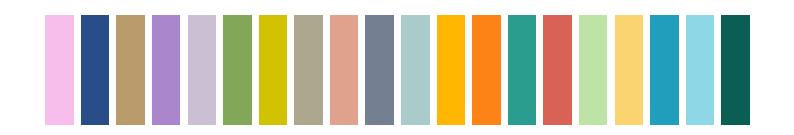

In [5]:
import matplotlib.pyplot as plt
cmap1 = plt.get_cmap('Dark2')
colors = ("#F7BEEC",'#284d88',"#BA9B6C","#AA87CD","#cbc0d3",
          '#83A759','#D1C301',"#ADA78F",'#E0A28C',"#748092",
          "#A9CBCA", "#ffb703","#FE8317",'#2A9D8F',"#d96256",
          '#BEE3A6',"#FAD471","#219ebc","#8ed7e6",'#0B5E53')

plt.figure(figsize=(10, 1.5))
plt.bar(range(len(colors)), height=1, color=colors)
__ = plt.axis('off')

93447
88620


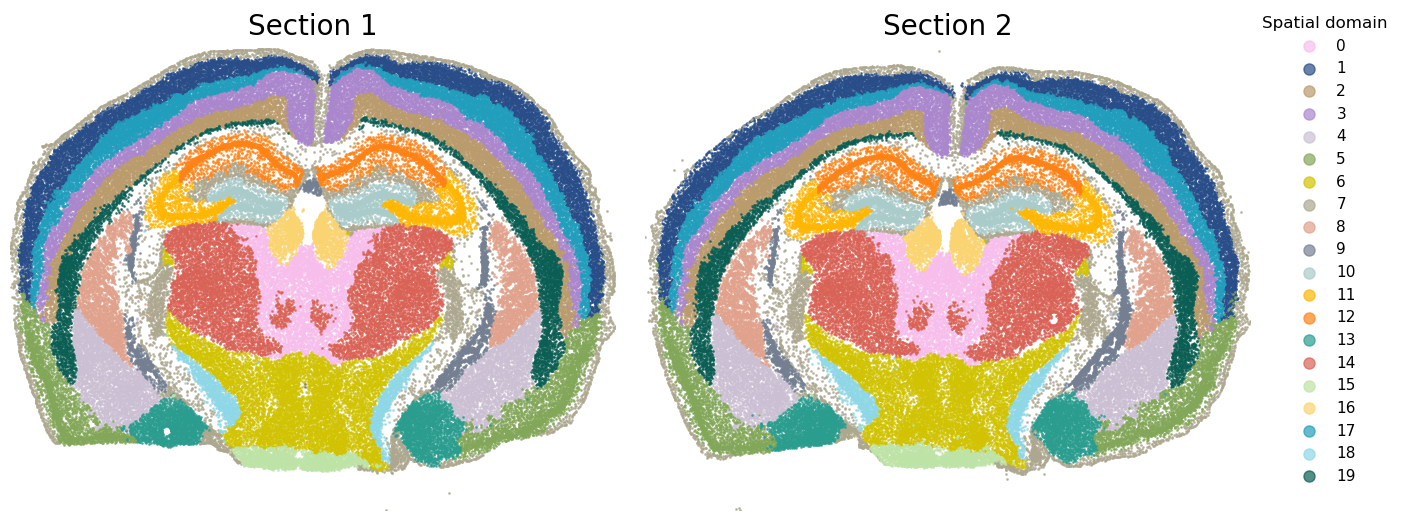

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.05})
unique_labels = np.unique(labels_total[labels_total != -1])

for i in range(len(unique_labels)):
    idx1 = np.where(labels_total_rep1 == i)
    idx2 = np.where(labels_total_rep2 == i)
    ax[0].scatter(location_rep1[:,0][idx1], location_rep1[:,1][idx1], s=1, alpha=0.7,label=f'{int(i)}',c=colors[int(i)])
    ax[1].scatter(location_rep2[:,0][idx2], location_rep2[:,1][idx2], s=1, alpha=0.7,label=f'{int(i)}',c=colors[int(i)])

ax[0].set_title('Section 1',fontsize=20,pad=10)
ax[0].set_xlim([location_rep1[:,0].min(), location_rep1[:,0].max()])
ax[0].set_ylim([location_rep1[:,1].min(), location_rep1[:,1].max()])


ax[1].set_title('Section 2',fontsize=20,pad=10)
ax[1].set_xlim([location_rep2[:,0].min(), location_rep2[:,0].max()])
ax[1].set_ylim([location_rep2[:,1].min(), location_rep2[:,1].max()])


ax[0].axis('off')
ax[1].axis('off')
plt.legend(title="Spatial domain", loc='upper right',bbox_to_anchor=(1.25, 1.1),markerscale=8,fontsize=11,frameon=False)

plt.setp(plt.gca().get_legend().get_title(), fontsize=12)

plt.show()

**visualize marker gene expression in each spatial domain**

In [ ]:
adata_rep1 = sc.read_10x_h5(f"{data_path}{dataset}/cell_feature_matrix_rep1.h5")
adata_rep2 = sc.read_10x_h5(f"{data_path}{dataset}/cell_feature_matrix_rep2.h5")
print(adata_rep1)
print(adata_rep2)

cell_names_rep1 =  np.loadtxt(f"{data_path}{dataset}/cell_names_rep1.txt", dtype=str)
cell_names_rep2 =  np.loadtxt(f"{data_path}{dataset}/cell_names_rep2.txt", dtype=str) 
cell_to_labels_rep1 = dict(zip(cell_names_rep1, labels_total_rep1))
cell_to_labels_rep2 = dict(zip(cell_names_rep2, labels_total_rep2))
adata_rep1.obs['labels'] = adata_rep1.obs.index.map(cell_to_labels_rep1)
adata_rep2.obs['labels'] = adata_rep2.obs.index.map(cell_to_labels_rep2)
adata = adata_rep1.concatenate(adata_rep2, batch_key='replicate', batch_categories=['replicate1', 'replicate2'])
print(adata)

AnnData object with n_obs × n_vars = 162033 × 248
    var: 'gene_ids', 'feature_types', 'genome'
AnnData object with n_obs × n_vars = 154654 × 248
    var: 'gene_ids', 'feature_types', 'genome'
AnnData object with n_obs × n_vars = 316687 × 248
    obs: 'labels', 'replicate'
    var: 'gene_ids', 'feature_types', 'genome'


In [38]:
marker_gene_names = ['Rasgrf2','Rorb','Fezf2','Rprm','Cplx3','Wfs1','Prss35','Prox1']
mean_expression_count_per_label = np.zeros((len(marker_gene_names),20))
for j in range(len(marker_gene_names)):
    transcripts_truth_j = adata[:,adata.var.index == marker_gene_names[j]]
    for i in range(20):
        transcripts_truth_j_i = transcripts_truth_j[transcripts_truth_j.obs['labels'] == i]
        transcripts_truth_j_i_X = transcripts_truth_j_i.X
        transcripts_truth_j_i_X_log1p = np.log1p(transcripts_truth_j_i_X)
        mean_expression_count_per_label[j,i] = transcripts_truth_j_i_X_log1p.mean()


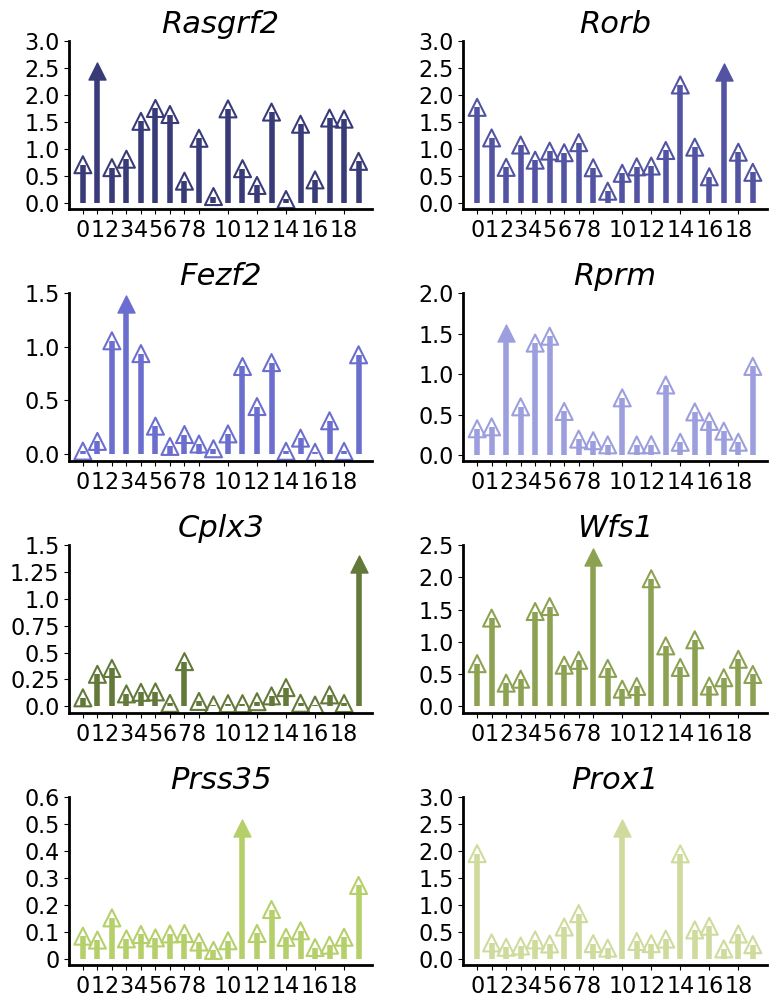

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(9, 12)) #12.5, 18)) 
gs = GridSpec(4, 2, width_ratios=[1, 1], wspace=0.3, hspace=0.5)
selected_domains = np.arange(20) 
k= 0 
axes = []
x_positions = np.arange(20) 
cmap = plt.cm.get_cmap('tab20b')          
colors = [cmap(i) for i in range(10)]  


for i in range(4):     
    for j in range(2):     
      
        ax = fig.add_subplot(gs[i, j])             
        axes.append(ax)
        heights = mean_expression_count_per_label[k]
        heights_top = np.argsort(heights)[::-1][:1]
        heights_not_top = np.argsort(heights)[::-1][1:]
        # 绘制垂直线
        ax.vlines(
            x=x_positions,          
            ymin=0,                 
            ymax=heights,          
            colors=colors[k],      
            linewidth=4,       
            label='Ground truth'   
        )

        ax.scatter(x=x_positions[heights_not_top],y=heights[heights_not_top], edgecolor=colors[k], s=150,marker='^',facecolor='none',linewidth=1.5)
        ax.scatter(x=x_positions[heights_top],y=heights[heights_top], color=colors[k], s=150,marker='^')
   
        ax.set_xticks([0,1,2,3,4,5,6,7,8,10,12,14,16,18])
        ax.set_xticklabels([0,1,2,3,4,5,6,7,8,10,12,14,16,18], fontsize=16)
        y_labels =ax.get_yticks()
        y_labels_positive = [i for i in y_labels if i >= 0]
        if marker_gene_names[k] =='Prss35':
            y_labels_positive = [0,0.1,0.2,0.3,0.4,0.5,0.6]
        elif marker_gene_names[k] =='Myl4':
            y_labels_positive = [0,0.2,0.4,0.6,0.8,1.0,1.2]
        ax.set_yticks(y_labels_positive)
        ax.set_yticklabels(y_labels_positive, fontsize=16)
        
        ax.set_title(f'{marker_gene_names[k]}', fontsize=22, fontstyle='italic')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        k+=1

plt.show()